In [165]:
import sys
import os
script_dir = os.getcwd()
sys.path.append(script_dir)

In [166]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [167]:
csvdata = pd.read_csv(r'Data\recommissioned_batteries\battery53.csv', low_memory=False)

In [168]:
def plot_variacao_temperatura(df):
    df = df.sort_values(by='time')
    
    plt.figure(figsize=(10, 6))
    variavel_foda_nova = [x for x in df["time"]]
    plt.plot(variavel_foda_nova, df['temperature_battery'], label='Temperatura da Bateria', color='red')

    plt.title('Variação da Temperatura da Bateria ao Longo do Tempo')
    plt.xlabel('Tempo segundos')
    plt.ylabel('Temperatura da Bateria (°C)')
    plt.grid(True)
    
    plt.legend()


    plt.show()


In [169]:
def plot_variacao_temperatura_suavizada(df, window_size=20):
    df = df.sort_values(by='time')

    plt.figure(figsize=(10, 6))

    plt.plot(df['time'], df['temperature_battery'], label='Temperatura Original', color='blue', alpha=1)

    # Plotando a série original com transparência para comparação
    

    plt.title('Variação da Temperatura da Bateria ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('Temperatura da Bateria (°C)')
    plt.grid(True)
    
    plt.legend()

    plt.show()


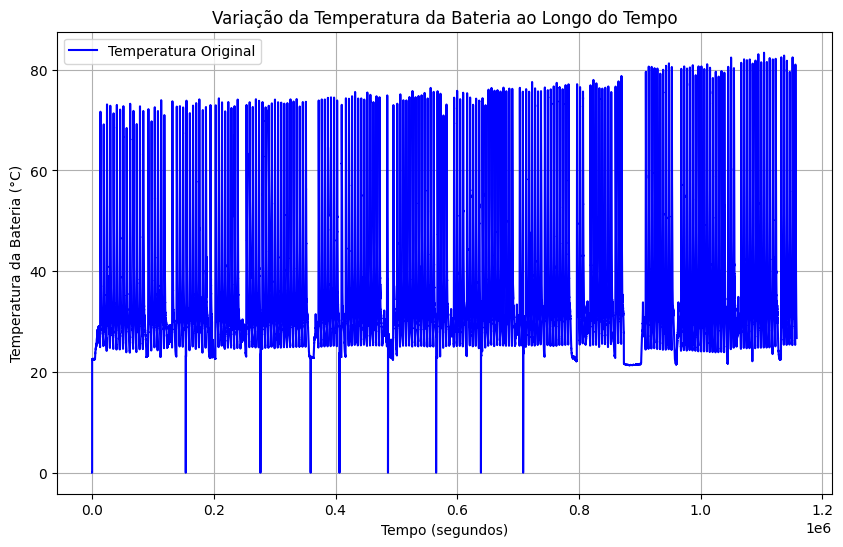

In [170]:
plot_variacao_temperatura_suavizada(csvdata)

In [171]:
def plot_variacao_temperatura_suavizada(df, window_size=20):
    df = df.sort_values(by='time')

    plt.figure(figsize=(10, 6))

    plt.plot(df['time'], df['voltage_charger'], label='voltage_charger', color='blue', alpha=1)
    # Plotando a série suavizada

    # Plotando a série original com transparência para comparação
    

    plt.title('Variação da voltage_charger ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('Volts')
    plt.grid(True)
    
    plt.legend()

    plt.show()


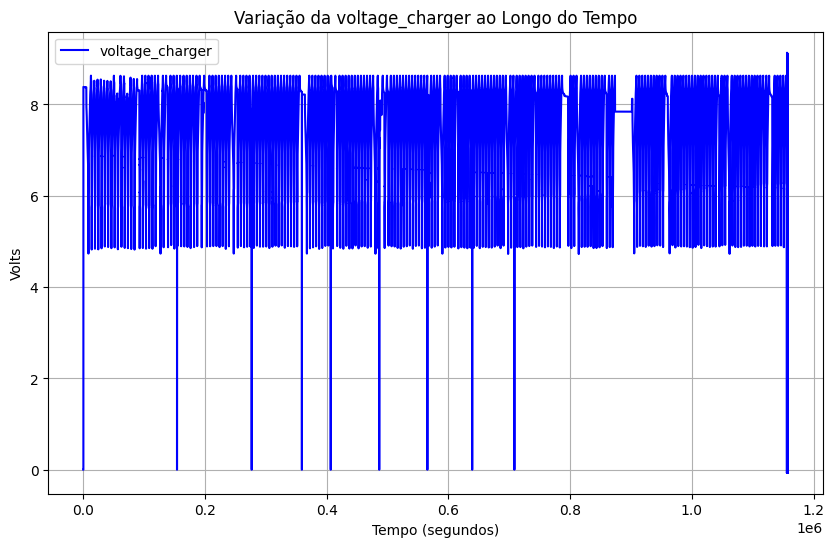

In [172]:
plot_variacao_temperatura_suavizada(csvdata)

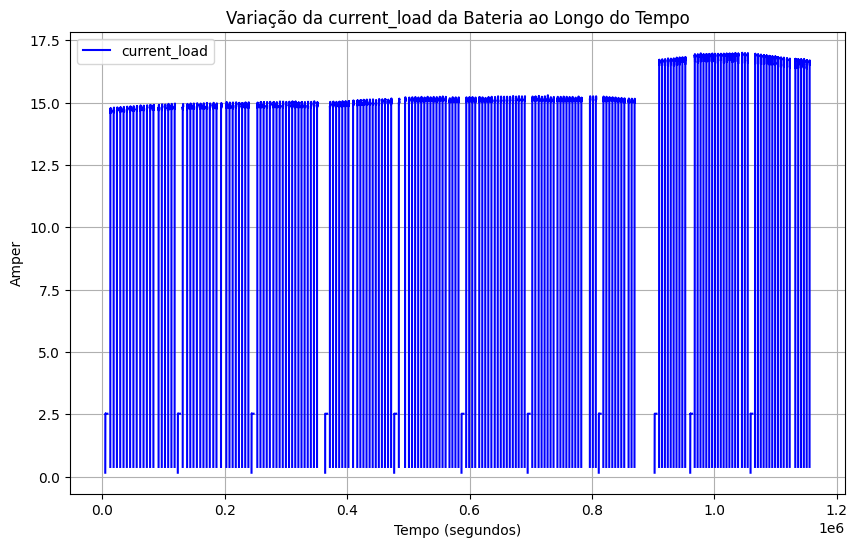

In [173]:
def plot_variacao_temperatura_suavizada(df, window_size=20):
    df = df.sort_values(by='time')


    plt.figure(figsize=(10, 6))

    plt.plot(df['time'], df['current_load'], label='current_load', color='blue', alpha=1)

    # Plotando a série original com transparência para comparação
    

    plt.title('Variação da current_load da Bateria ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('Amper')
    plt.grid(True)
    
    plt.legend()

    plt.show()

plot_variacao_temperatura_suavizada(csvdata)

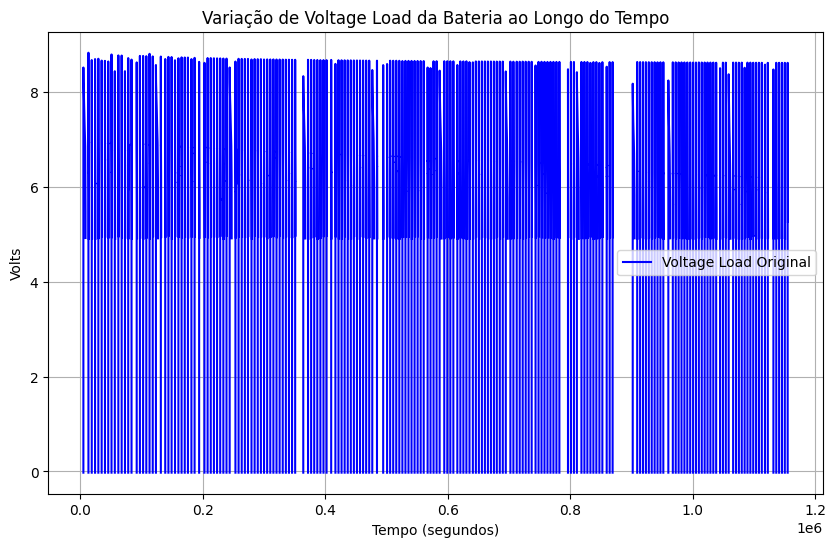

In [174]:
def plot_variacao_voltage_suavizada(df):
    df = df.sort_values(by='time')

    plt.figure(figsize=(10, 6))

    # Plotando a série original com transparência
    plt.plot(df['time'], df['voltage_load'], label='Voltage Load Original', color='blue', alpha=1)

    plt.title('Variação de Voltage Load da Bateria ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('Volts')
    plt.grid(True)
    
    plt.legend()

    plt.show()

# Exemplo de uso
plot_variacao_voltage_suavizada(csvdata)


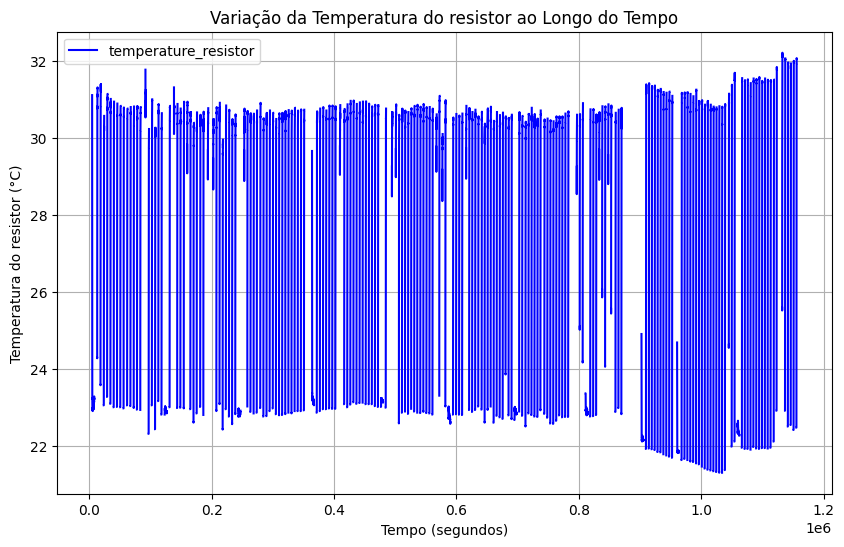

In [181]:
def plot_variacao_temperatura_suavizada(df, window_size=20):
    df = df.sort_values(by='time')
    
    plt.figure(figsize=(10, 6))

    plt.plot(df['time'], df['temperature_resistor'], label='temperature_resistor', color='blue', alpha=1)
    # Plotando a série original com transparência para comparação
    

    plt.title('Variação da Temperatura do resistor ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('Temperatura do resistor (°C)')
    plt.grid(True)
    
    plt.legend()

    plt.show()

plot_variacao_temperatura_suavizada(csvdata)

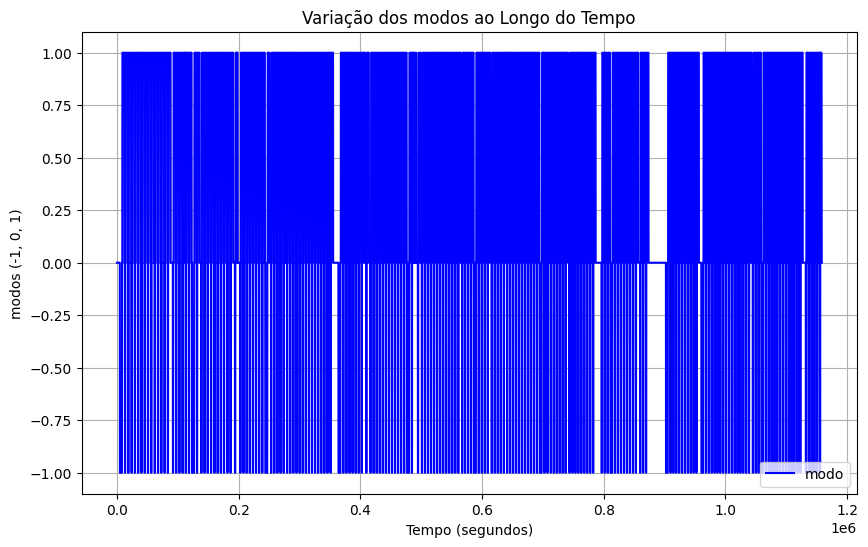

In [176]:
def plot_variacao_temperatura_suavizada(df, window_size=20):
    df = df.sort_values(by='time')
    
    plt.figure(figsize=(10, 6))

    plt.plot(df['time'], df['mode'], label='modo', color='blue', alpha=1)
    # Plotando a série original com transparência para comparação
    

    plt.title('Variação dos modos ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('modos (-1, 0, 1)')
    plt.grid(True)
    
    plt.legend()

    plt.show()

plot_variacao_temperatura_suavizada(csvdata)

In [177]:
def calcular_tempos_e_medias(df):
    """
    Função que calcula a diferença de tempo entre as transições de 'mode' para -1 e de -1 para qualquer outro valor,
    além de calcular a média de 'current_load' para o intervalo de tempo correspondente.

    Parâmetros:
    df (pandas.DataFrame): O DataFrame contendo as colunas 'mode', 'time' e 'current_load'.
    
    Retorno:
    list: Lista de listas, onde cada sub-lista contém a diferença de tempo e a média de 'current_load' para o intervalo.
    """
    resultados = []
    start_time = None
    start_index = None

    for i in range(1, len(df)):
        # Verificar transição de qualquer valor para -1
        if df['mode'].iloc[i] == -1 and df['mode'].iloc[i - 1] != -1:
            # Armazena o valor de 'time' e o índice de início da transição
            start_time = df['time'].iloc[i]
            start_index = i
        
        # Verificar transição de -1 para qualquer outro valor
        elif df['mode'].iloc[i] != -1 and df['mode'].iloc[i - 1] == -1 and start_time is not None:
            # Armazena o valor de 'time' quando sair de -1
            end_time = df['time'].iloc[i]
            # Calcula o módulo da diferença de tempo entre o início e o fim da transição
            tempo_total = abs(end_time - start_time)

            # Calcula a média de 'current_load' no intervalo entre start_index e i
            media_current_load = df['current_load'].iloc[start_index:i].mean()

            # Adiciona o tempo total e a média de 'current_load' como uma sub-lista
            resultados.append((tempo_total / 3600) * media_current_load)

            # Reseta os valores de start_time e start_index para a próxima transição
            start_time = None
            start_index = None
    
    return resultados


In [178]:
# Supondo que você tenha um DataFrame 'df_bateria' com as colunas 'mode' e 'time'
tempos_transicoes = calcular_tempos_e_medias(csvdata)

# Exibir a lista de tempos calculados
print(tempos_transicoes)


[2.4535940231632276, 2.455177613259198, 2.407415863173923, 2.4148004542351393, 2.418419489837087, 2.40079002372311, 2.397178402848766, 2.3929915662602697, 2.4422143035183232, 2.1914539088774228, 2.4386949928526134, 2.4340703884626604, 2.191274489261592, 2.41697500446072, 2.405380183465561, 2.3994843794905085, 2.4190463591980196, 2.4211428592688917, 2.4154101955415133, 2.438036410032625, 2.4103334791112916, 2.410557483240814, 2.40691909789889, 2.4118066296815597, 2.4001147351540704, 2.4016505387636746, 2.392064780878074, 2.3987907832884607, 2.3904924741968707, 2.38569760791894, 2.3851627906114716, 2.3809056090659806, 2.376592853181699, 2.381275397071234, 2.3615485769632216, 2.365827005245877, 2.365426453338632, 2.3595359009589414, 2.3605799569097488, 2.3574471682892204, 2.3580538471464205, 2.3526991856215074, 2.352334241202981, 2.357015692921971, 2.3466814339419093, 2.3457515597801692, 2.3431350473495307, 2.341232031067047, 2.334245064083599, 2.3345648149770186, 2.334243728324452, 2.332

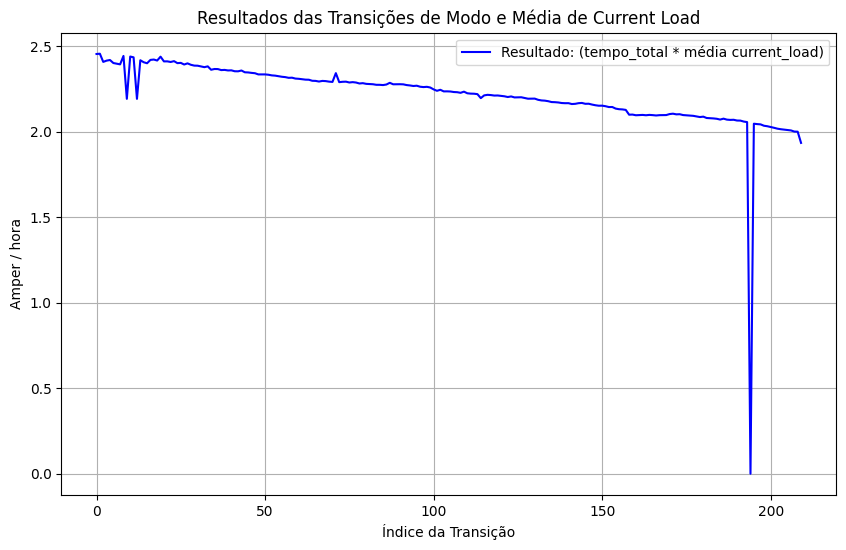

In [179]:
def plotar_resultados(tempos_transicoes):
    """
    Função que plota os resultados obtidos pela função calcular_tempos_e_medias.
    
    Parâmetros:
    tempos_transicoes (list): Lista de resultados contendo os valores (tempo * média de current_load).
    """
    plt.figure(figsize=(10, 6))
    
    # Plotar o resultado
    plt.plot(range(len(tempos_transicoes)), tempos_transicoes, color='blue', label='Resultado: (tempo_total * média current_load)')

    # Configurações do gráfico
    plt.title('Resultados das Transições de Modo e Média de Current Load')
    plt.xlabel('Índice da Transição')
    plt.ylabel('Amper / hora')
    plt.grid(True)
    plt.legend()

    # Mostrar o gráfico
    plt.show()

# Plotar o gráfico com os resultados obtidos da função calcular_tempos_e_medias
plotar_resultados(tempos_transicoes)


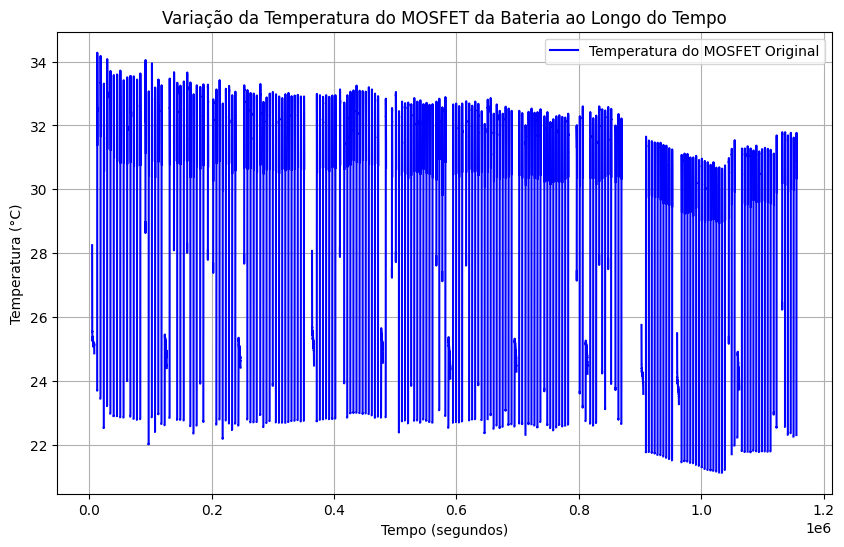

In [180]:
def plot_variacao_temperatura_mosfet(df):
    df = df.sort_values(by='time')

    plt.figure(figsize=(10, 6))

    # Plotando a série original com transparência
    plt.plot(df['time'], df['temperature_mosfet'], label='Temperatura do MOSFET Original', color='blue', alpha=1)

    plt.title('Variação da Temperatura do MOSFET da Bateria ao Longo do Tempo')
    plt.xlabel('Tempo (segundos)')
    plt.ylabel('Temperatura (°C)')
    plt.grid(True)
    
    plt.legend()

    plt.show()

# Exemplo de uso
plot_variacao_temperatura_mosfet(csvdata)


In [182]:
a = [4713.48,
  3039.11,
  3512.38,
  29.013,
  22.572,
  26.016,
  1.887,
  22.0,
  -0.026,
  15.329,
  7.269,
  22.0,
  0.152,
  13.079,
  9.706,
  25.53,
  22.0,
  23.469,
  1.609,
  23.19,
  22.0,
  22.516,
  0.562,
  12.761,
  1]

len(a)

25